In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Método de derivacion numerica de Richardson (ver apuntes MEN tema 5). Se calcula por columnas como:

$D(I,0) = D_0(\frac{h}{2^I})$ y $D(I,K) = \frac{4^K D(I,K-1) - D(I-1,K-1)}{4^K - 1}$ , 

donde $D_0(h) \approx f'(x_0) = \frac{f(x_0 + h) - f(x_0-h)}{2h}$. 

Por lo tanto, necesitamos conocer $f(x)$, el punto donde queremos hallar la derivada $x_0$ y el tamaño del paso $h$.

In [2]:
def D_0(func,x0,h):
    # func = funcion f(x)
    # x0 = punto donde evaluamos la derivada
    # h = tamaño del paso

    d0 = (func(x0+h)-func(x0-h)) / (2*h)

    return d0

Teniendo $D_0$ definida ahora lo que hacemos es calcular por columnas, es decir $D(1,1),D(1,2),D(1,3)...$ y lo mismo con las siguientes columnas.

In [3]:
def D_k(func,x0,h,k):
    # func = funcion a derivar
    # x0 = punto donde evaluamos la derivada
    # h = tamaño del paso
    # k = orden/iteraciones para el calculo de la derivada 

    d_k = np.zeros((k+1,k+1)) # Defino una matriz de dimension k+1 vacia

    for m in range (0,k+1,1): # Lo que hago es calcular la columnas de D_0's
        d_k[m][0] = D_0(func,x0,h/(2**m)) 

    for j in range (1,k+1,1):
        for i in range (j,k+1,1): # Calculo por columnas: columna 1 y paso por todas las filas; columna 2 y todas las filas; etc
            d_k[i][j] = (((4**j)*d_k[i][j-1]) - d_k[i-1][j-1]) / ((4**j) - 1)

    return d_k[k][k] # Valor de f'(x0)

Programa principal suponiendo que $f(x)$ es $f(x) = 5x^2 - \sin(x)$. Sabemos que el valor simbólico de $f'(x)$ es $f'(x)=10x - \cos(x)$, por lo que podemos comparar ambas soluciones de una manera gráfica.

In [4]:
def f(x):
    valor = 5*(x**2) - np.sin(x)
    return valor

def fprime(x): # La defino para hacer una comprobacion grafica, pero realmente es innecesaria definirla
    valorp = 10*x - np.cos(x)
    return valorp

x0=5
h=0.1
k=3
solucion = D_k(f,x0,h,k) #Valor aproximado de f'(x0)

print("El valor de la derivada de f(x) en el punto ", x0, " es ", solucion, ".")

El valor de la derivada de f(x) en el punto  5  es  49.71633781453717 .


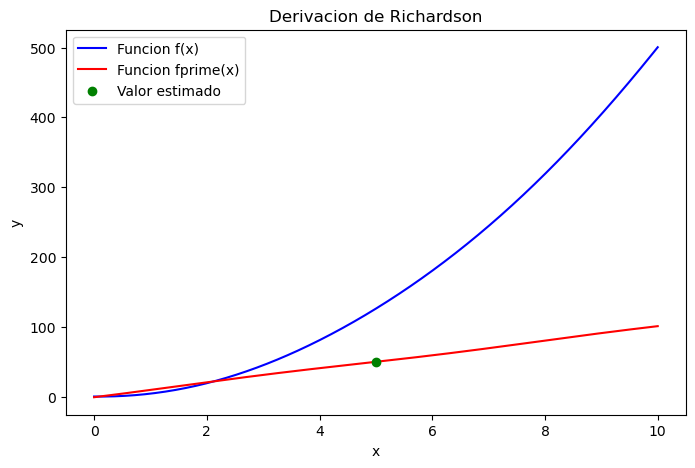

In [5]:
# Comprobacion grafica 

x_vals = np.linspace(0, 10, 500) # x0 = 5 , si fuera otro valor modificar el rango de x_vals
y_vals = f(x_vals)
yprime_vals = fprime(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='Funcion f(x)', color='blue')
plt.plot(x_vals, yprime_vals, label='Funcion fprime(x)', color='red')
plt.scatter(x0, solucion, color='green', label='Valor estimado', zorder=5)
plt.title('Derivacion de Richardson')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(False)
plt.show()